In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("Global YouTube Statistics.csv", encoding='latin-1')

In [5]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


# Deleting Redundant Columns 
Since there is no redundant column in this data set  no droping any column

In [6]:
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')

In [38]:
len(df.columns)


28

# Renaming Columns 

In [7]:
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')

In [8]:
df.columns=[col.title() for col in df.columns]

In [50]:
df.head()

,Rank,Youtuber,Subscribers,Video Views,Category,Title,Uploads,Country,Abbreviation,Channel_Type,...,Subscribers_For_Last_30_Days,Created_Year,Created_Month,Created_Date,Gross Tertiary Education Enrollment (%),Population,Unemployment Rate,Urban_Population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


# Dropping Duplicates 

In [9]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.isna().sum().sort_values(ascending=False)

Subscribers_For_Last_30_Days               337
Latitude                                   123
Urban_Population                           123
Longitude                                  123
Population                                 123
Gross Tertiary Education Enrollment (%)    123
Unemployment Rate                          123
Abbreviation                               122
Country                                    122
Country_Rank                               116
Video_Views_For_The_Last_30_Days            56
Category                                    46
Channel_Type_Rank                           33
Channel_Type                                30
Created_Month                                5
Created_Year                                 5
Created_Date                                 5
Video_Views_Rank                             1
Rank                                         0
Youtuber                                     0
Title                                        0
Uploads      

# Null Values Analysis

In [10]:
df.isna().sum().sum()

np.int64(1616)

In [11]:
df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100

np.float64(5.8004307250538405)

In [60]:
Nan_percntage=df.isna().sum()/df.shape[0]*100

In [61]:
Info_df=pd.DataFrame({"Missing_Values":df.isna().sum(),"Percentage":Nan_percntage})
Info_df=Info_df.sort_values(by=["Percentage","Missing_Values"],ascending=False)
Info_df["Percentage"]=Info_df["Percentage"].round(2)
print("           MISSING VALUES ANALYSIS")
print("_"*40)
print(Info_df)

           MISSING VALUES ANALYSIS
________________________________________
                                         Missing_Values  Percentage
Subscribers_For_Last_30_Days                        337       33.87
Gross Tertiary Education Enrollment (%)             123       12.36
Population                                          123       12.36
Unemployment Rate                                   123       12.36
Urban_Population                                    123       12.36
Latitude                                            123       12.36
Longitude                                           123       12.36
Country                                             122       12.26
Abbreviation                                        122       12.26
Country_Rank                                        116       11.66
Video_Views_For_The_Last_30_Days                     56        5.63
Category                                             46        4.62
Channel_Type_Rank                       

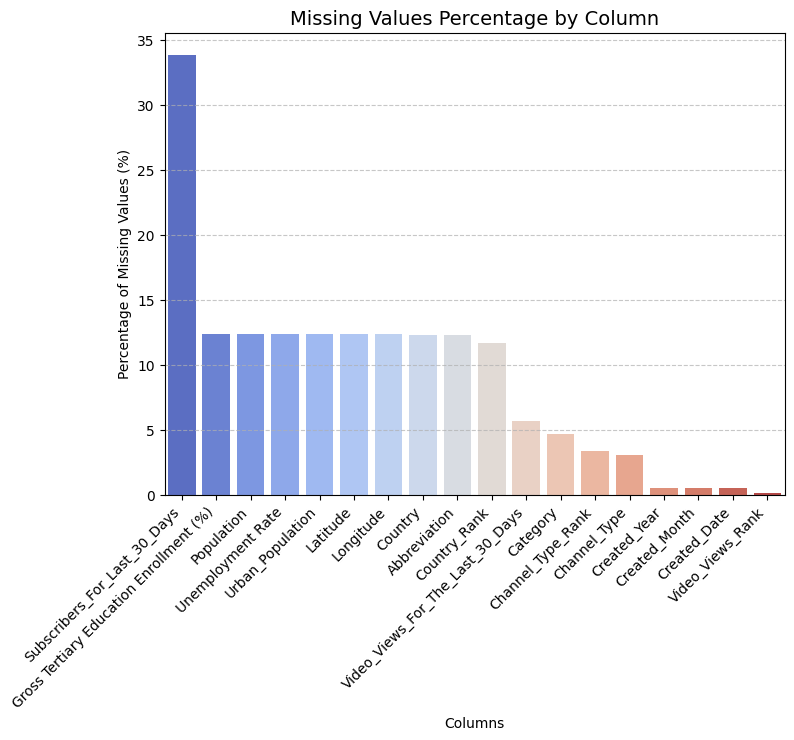

In [13]:
Nan_percntage=df.isna().sum()/df.shape[0]*100
Info_df=pd.DataFrame({"Missing_Values":df.isna().sum(),"Percentage":Nan_percntage})
Info_df=Info_df.sort_values(by=["Percentage","Missing_Values"],ascending=False)
Info_df["Percentage"]=Info_df["Percentage"].round(2)

missing_df = Info_df[Info_df["Missing_Values"] > 0]

plt.figure(figsize=(8, 6))

sns.barplot(x=missing_df.index, y=missing_df["Percentage"], palette="coolwarm")

plt.title("Missing Values Percentage by Column", fontsize=14)
plt.ylabel("Percentage of Missing Values (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45,ha="right")

plt.grid(axis='y', linestyle='--', alpha=1)

plt.grid(axis='y', alpha=0.7)

plt.show()

# Hndlinding NAN Values in the Dataset

In [14]:

df.drop(columns=['Subscribers_For_Last_30_Days'], inplace=True)

num_cols = ['Gross Tertiary Education Enrollment (%)', 'Population', 'Unemployment Rate',
            'Urban_Population', 'Latitude', 'Longitude', 'Country_Rank',
            'Video_Views_For_The_Last_30_Days']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = ['Country', 'Abbreviation', 'Category', 'Channel_Type',
            'Created_Year', 'Created_Month', 'Created_Date']

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [15]:
df.isna().sum()

Rank                                        0
Youtuber                                    0
Subscribers                                 0
Video Views                                 0
Category                                    0
Title                                       0
Uploads                                     0
Country                                     0
Abbreviation                                0
Channel_Type                                0
Video_Views_Rank                            1
Country_Rank                                0
Channel_Type_Rank                          33
Video_Views_For_The_Last_30_Days            0
Lowest_Monthly_Earnings                     0
Highest_Monthly_Earnings                    0
Lowest_Yearly_Earnings                      0
Highest_Yearly_Earnings                     0
Created_Year                                0
Created_Month                               0
Created_Date                                0
Gross Tertiary Education Enrollmen

In [16]:
df["Channel_Type_Rank"]=df["Channel_Type_Rank"].dropna()

In [17]:



df["Video_Views_Rank"]=df["Video_Views_Rank"].dropna()

In [18]:
df.isnull().sum().sum()

np.int64(34)

In [19]:
df.dropna(inplace=True)

# Cleaning Individual Columns 

In [20]:
df.head()

,Rank,Youtuber,Subscribers,Video Views,Category,Title,Uploads,Country,Abbreviation,Channel_Type,...,Highest_Yearly_Earnings,Created_Year,Created_Month,Created_Date,Gross Tertiary Education Enrollment (%),Population,Unemployment Rate,Urban_Population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,1.084000e+08,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,5.800000e-01,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,6.470000e+07,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,9.480000e+07,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,8.750000e+07,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [21]:
df.shape[1]

27

In [75]:
len(df.describe().columns.tolist())

20

In [76]:
len(df.describe(include="object").columns.tolist())

7

gertting normal not scientific numbers

In [81]:
pd.set_option('display.float_format',"{:.2f}".format)

AVERAGE SUBSCRIBERS BY CATEGORY

In [22]:
category_subscribers_mean=df.groupby("Category")["Subscribers"].mean().sort_values(ascending=False)
category_subscribers_mean

Category
Shows                    4.350833e+07
Trailers                 3.900000e+07
Film & Animation         2.859111e+07
Nonprofits & Activism    2.775000e+07
Sports                   2.710909e+07
Education                2.654222e+07
Music                    2.568939e+07
Movies                   2.565000e+07
Entertainment            2.158613e+07
People & Blogs           2.110859e+07
Gaming                   2.078696e+07
News & Politics          2.063077e+07
Comedy                   1.965909e+07
Pets & Animals           1.940000e+07
Science & Technology     1.900000e+07
Howto & Style            1.861892e+07
Autos & Vehicles         1.785000e+07
Travel & Events          1.250000e+07
Name: Subscribers, dtype: float64

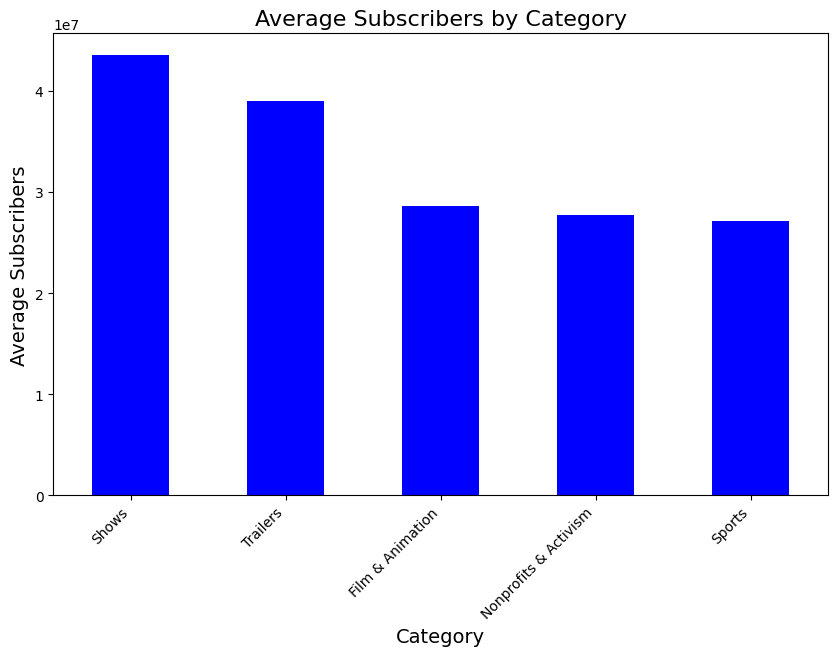

In [84]:
category_subscribers_mean.head().plot(kind="bar", figsize=(10,6), color='blue')
plt.title("Average Subscribers by Category", fontsize=16)
plt.xlabel("Category", fontsize=14)
plt.ylabel("Average Subscribers", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

In [85]:
channel_types_counts=df["Channel_Type"].value_counts()
channel_types_counts

Channel_Type
Entertainment    304
Music            214
People           101
Games             98
Comedy            50
Education         49
Film              42
Howto             36
News              30
Tech              17
Sports            13
Autos              3
Animals            3
Nonprofit          2
Name: count, dtype: int64

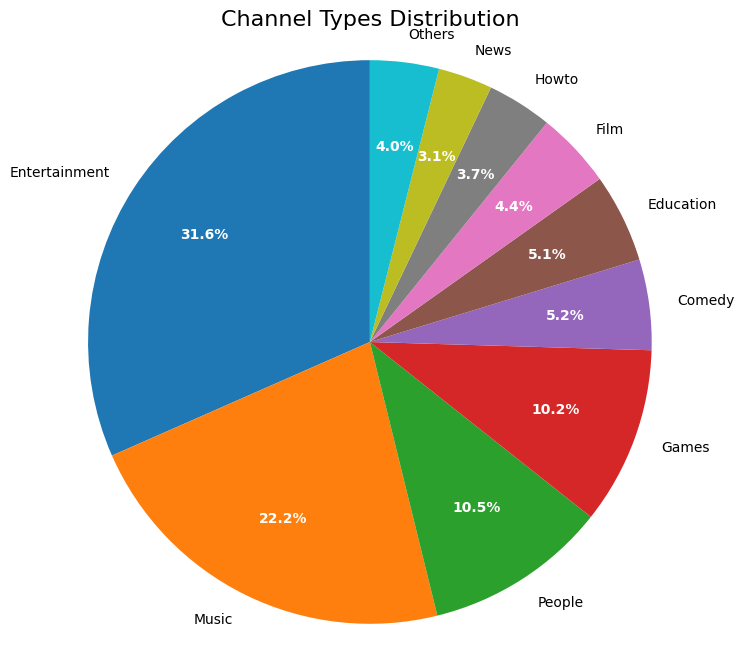

In [ ]:


channel_types_counts = df["Channel_Type"].value_counts()

# Group small categories (<3%) into "Others"
threshold = 0.03 * channel_types_counts.sum()
small = channel_types_counts[channel_types_counts < threshold]
large = channel_types_counts[channel_types_counts >= threshold]

channel_grouped = large.copy()
channel_grouped["Others"] = small.sum()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    channel_grouped,
    labels=channel_grouped.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title("Channel Types Distribution", fontsize=16)
ax.axis('equal')

plt.show()

In [89]:
df["Video Views"]

0     228000000000.00
1                0.00
2      28368841870.00
3     164000000000.00
4     148000000000.00
            ...      
990     9029609749.00
991     1674409945.00
992     2214684303.00
993      374123483.00
994     2129773714.00
Name: Video Views, Length: 962, dtype: float64

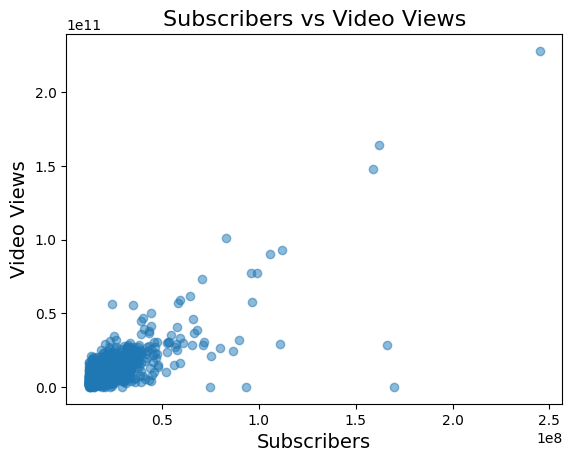

In [90]:
plt.scatter(df["Subscribers"], df["Video Views"], alpha=0.5)
plt.title("Subscribers vs Video Views", fontsize=16)
plt.xlabel("Subscribers", fontsize=14)
plt.ylabel("Video Views", fontsize=14)
plt.show()

In [93]:
country_by_subscribers=df.groupby("Country")["Subscribers"].sum().sort_values(ascending=False)
country_by_subscribers.head()

Country
United States     9596300000
India             4284200000
Brazil            1207300000
United Kingdom     917400000
Mexico             586300000
Name: Subscribers, dtype: int64

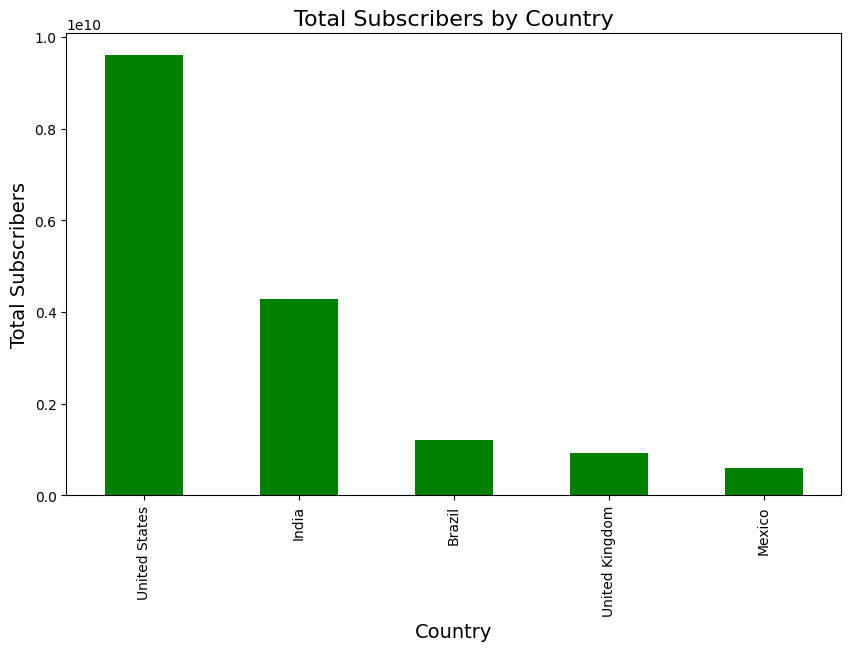

In [94]:
country_by_subscribers.head().plot(kind="bar", figsize=(10,6), color='green')
plt.title("Total Subscribers by Country", fontsize=16)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Total Subscribers", fontsize=14)
plt.show()


<Axes: xlabel='Created_Year'>

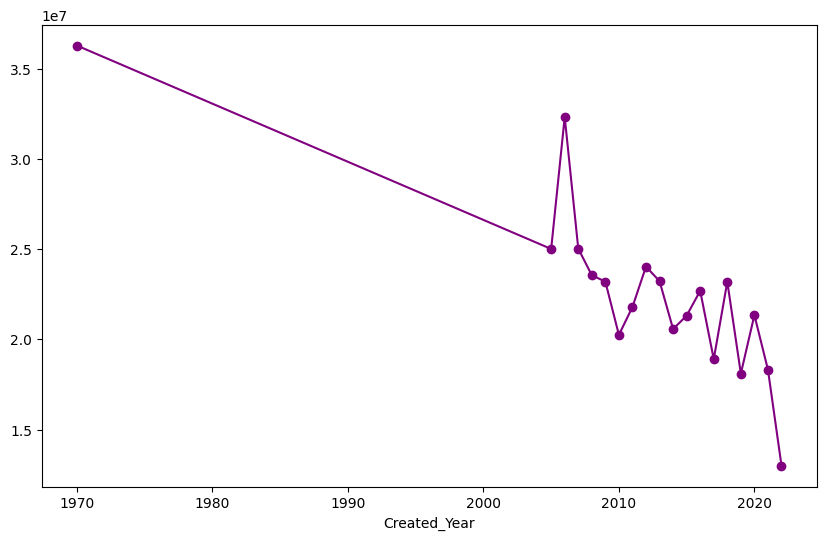

In [95]:
df.groupby("Created_Year")["Subscribers"].mean().plot(kind="line", figsize=(10,6), marker='o', color='purple')

In [100]:
channel_type_views=df.groupby("Channel_Type")["Video Views"].mean().sort_values(ascending=False)#.plot(kind="bar", figsize=(10,6), color='orange')
channel_type_views

Channel_Type
Education       15608284350.43
Music           15188297827.68
Animals         14711751867.00
Sports          13931151670.08
Entertainment   11091753573.09
Film            10934351185.88
News            10378427263.67
Comedy           8889402010.36
People           8771476334.57
Games            7414358687.48
Autos            6525848803.33
Howto            5434739663.61
Nonprofit        5431455892.50
Tech             3491502148.71
Name: Video Views, dtype: float64

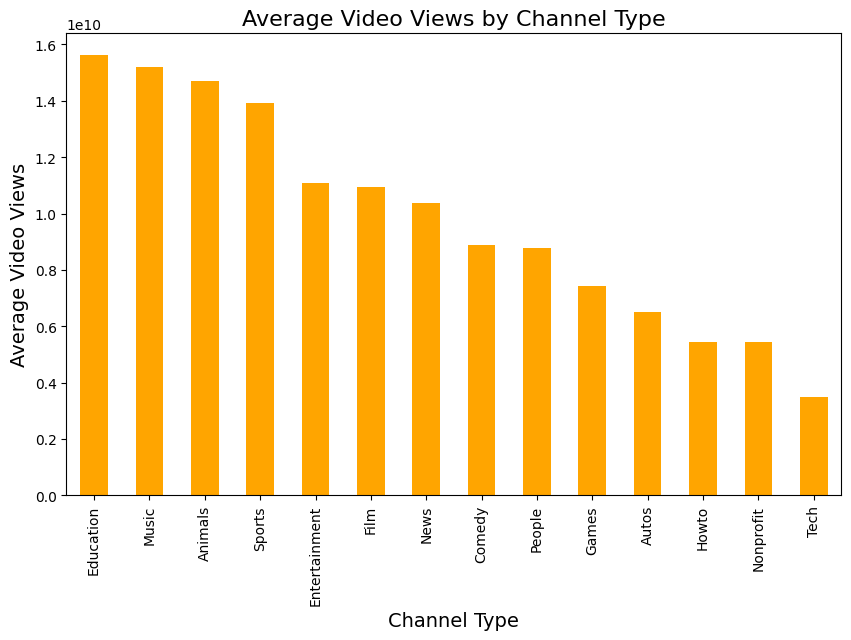

In [101]:
channel_type_views.plot(kind="bar", figsize=(10,6), color='orange')
plt.title("Average Video Views by Channel Type", fontsize=16)
plt.xlabel("Channel Type", fontsize=14)
plt.ylabel("Average Video Views", fontsize=14)
plt.show()

In [103]:
df.columns

Index(['Rank', 'Youtuber', 'Subscribers', 'Video Views', 'Category', 'Title',
       'Uploads', 'Country', 'Abbreviation', 'Channel_Type',
       'Video_Views_Rank', 'Country_Rank', 'Channel_Type_Rank',
       'Video_Views_For_The_Last_30_Days', 'Lowest_Monthly_Earnings',
       'Highest_Monthly_Earnings', 'Lowest_Yearly_Earnings',
       'Highest_Yearly_Earnings', 'Created_Year', 'Created_Month',
       'Created_Date', 'Gross Tertiary Education Enrollment (%)', 'Population',
       'Unemployment Rate', 'Urban_Population', 'Latitude', 'Longitude'],
      dtype='object')

In [108]:
contry_last_30=df.groupby("Country")["Video_Views_For_The_Last_30_Days"].median().sort_values(ascending=False).head()

In [112]:
contry_last_30

Country
Latvia     1245000000.00
Pakistan    684860000.00
Italy       627435000.00
Japan       282372000.00
Turkey      267810500.00
Name: Video_Views_For_The_Last_30_Days, dtype: float64

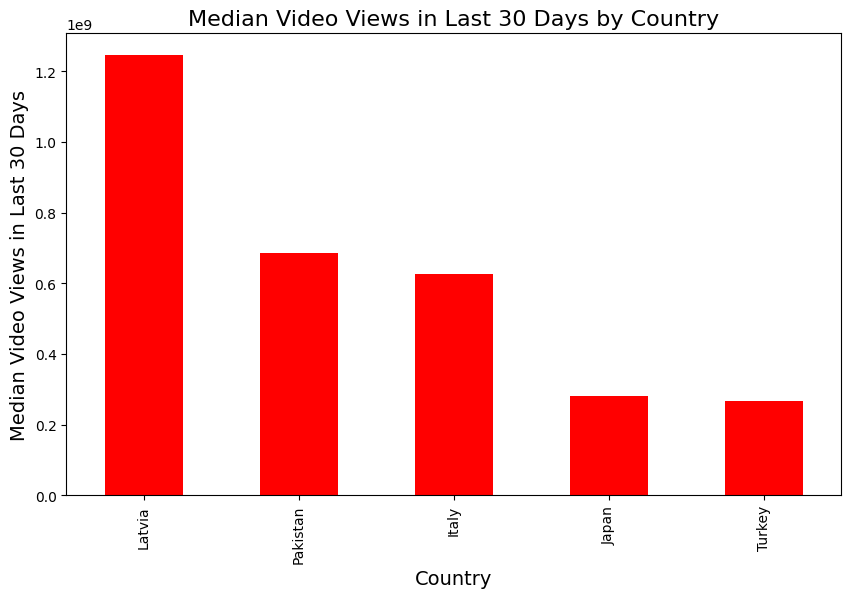

In [111]:
contry_last_30.plot(kind="bar", figsize=(10,6), color='red')
plt.title("Median Video Views in Last 30 Days by Country", fontsize=16)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Median Video Views in Last 30 Days", fontsize=14)
plt.show()

In [113]:
country_channel_rank=df.groupby("Country")['Channel_Type_Rank'].mean().sort_values(ascending=True).head()

In [114]:
country_channel_rank

Country
El Salvador    3.00
Switzerland    5.00
Kuwait         7.00
China         16.00
Latvia        19.00
Name: Channel_Type_Rank, dtype: float64

In [116]:
df.groupby("Category")["Video Views"].std()

Category
Autos & Vehicles         2964425983.84
Comedy                   6344799863.86
Education               25572139026.30
Entertainment            9953534514.75
Film & Animation        11019515626.90
Gaming                   5885362484.26
Howto & Style            4337839289.72
Movies                   3353301875.46
Music                   17892982039.69
News & Politics          5165961804.90
Nonprofits & Activism    2698145850.47
People & Blogs          12665439042.97
Pets & Animals           7864203116.00
Science & Technology     3032462497.54
Shows                   44932051396.82
Sports                  21703831459.30
Trailers                 1382496086.18
Travel & Events                    NaN
Name: Video Views, dtype: float64

In [118]:
df.groupby("Country")["Unemployment Rate"].mean().sort_values(ascending=False)

Country
Jordan                 14.72
Spain                  13.96
Turkey                 13.49
United States          13.43
Iraq                   12.82
Brazil                 12.08
Afghanistan            11.12
Egypt                  10.76
Barbados               10.33
Italy                   9.89
Argentina               9.79
Colombia                9.71
Andorra                 9.37
Morocco                 9.02
Ukraine                 8.88
Venezuela               8.80
France                  8.43
Samoa                   8.36
Chile                   7.09
Finland                 6.59
Latvia                  6.52
Sweden                  6.48
Saudi Arabia            5.93
Canada                  5.56
India                   5.36
Australia               5.27
Indonesia               4.69
Russia                  4.59
Switzerland             4.58
Pakistan                4.45
China                   4.32
Bangladesh              4.19
South Korea             4.15
El Salvador             4.11
Singap

In [121]:
df.groupby('Channel_Type')["Uploads"].sum().sort_values(ascending=False)

Channel_Type
News             3989151
Entertainment    3345035
Music             424950
Games             399473
Nonprofit         205824
Sports            158995
Education         146355
People            117424
Film              114654
Comedy             81722
Howto              79417
Animals            42868
Tech               33780
Autos                949
Name: Uploads, dtype: int64

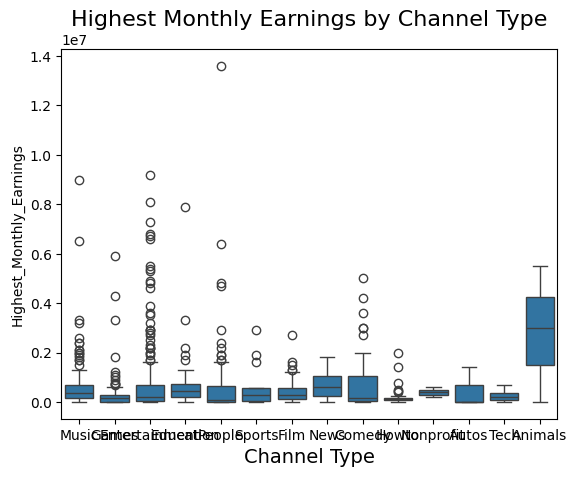

In [122]:
sns.boxplot(data=df, x="Channel_Type", y="Highest_Monthly_Earnings")
plt.title("Highest Monthly Earnings by Channel Type", fontsize=16)
plt.xlabel("Channel Type", fontsize=14)
plt.show()

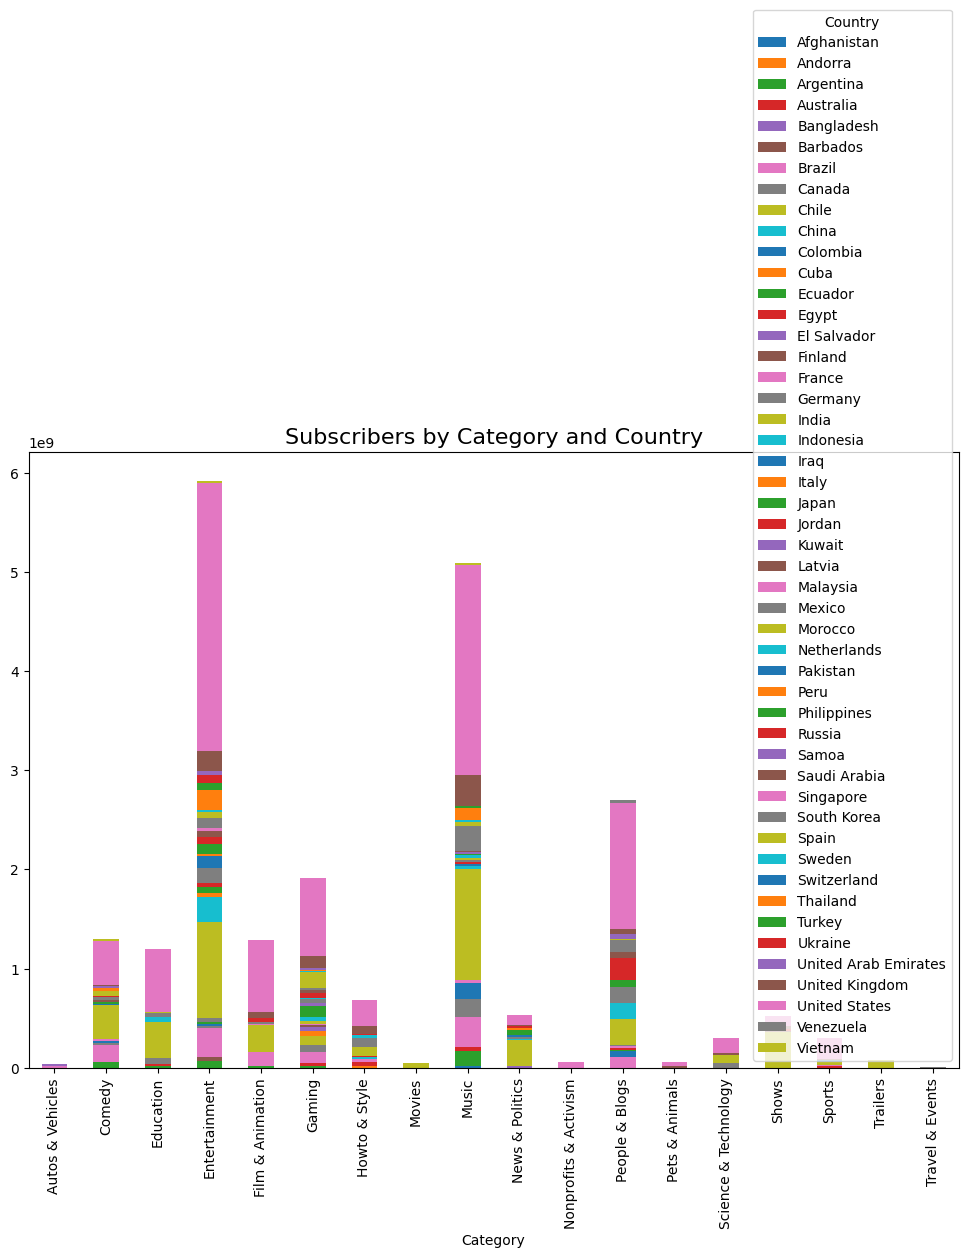

In [123]:
df.groupby(["Category","Country"])["Subscribers"].sum().unstack().plot(kind="bar", figsize=(12,8),stacked=True)
plt.title("Subscribers by Category and Country", fontsize=16)
plt.show()

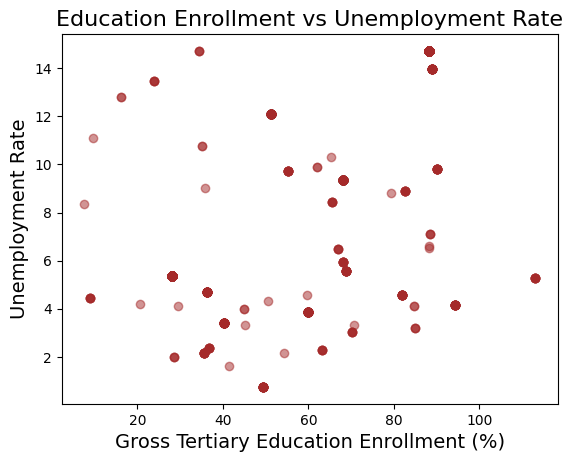

In [124]:
plt.scatter(df["Gross Tertiary Education Enrollment (%)"], df["Unemployment Rate"], alpha=0.5, color='brown')
plt.title("Education Enrollment vs Unemployment Rate", fontsize=16)
plt.xlabel("Gross Tertiary Education Enrollment (%)", fontsize=14)
plt.ylabel("Unemployment Rate", fontsize=14)
plt.show()

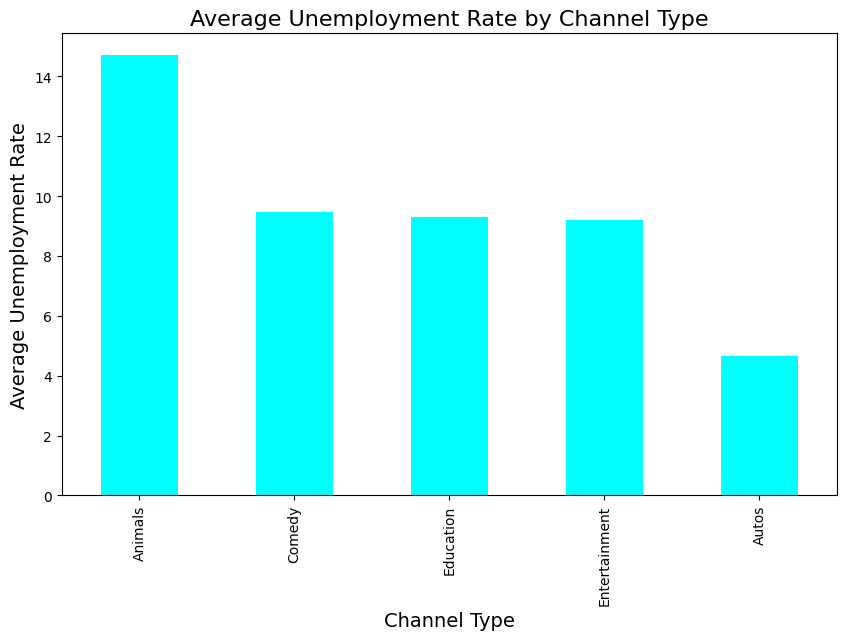

In [127]:
df.groupby("Channel_Type")["Unemployment Rate"].mean().head().sort_values(ascending=False).plot(kind="bar", figsize=(10,6), color='cyan')
plt.title("Average Unemployment Rate by Channel Type", fontsize=16)
plt.xlabel("Channel Type", fontsize=14)
plt.ylabel("Average Unemployment Rate", fontsize=14)
plt.show()

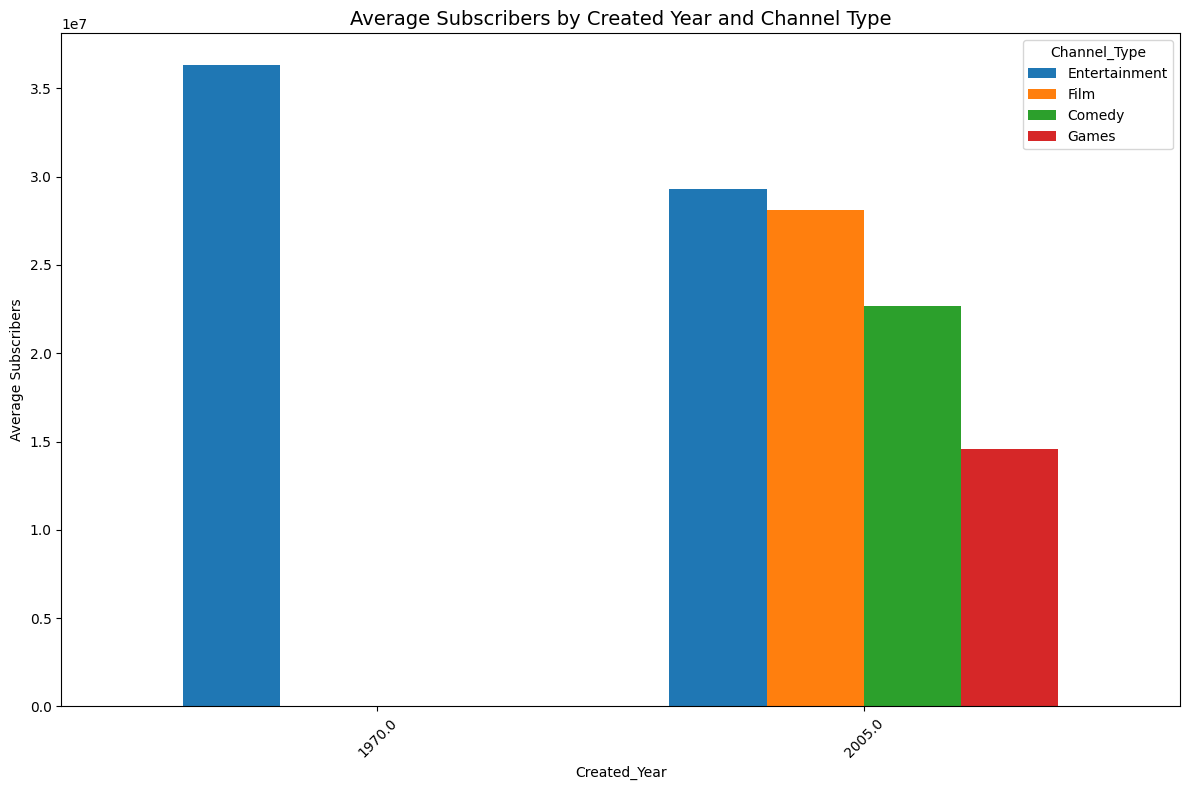

In [133]:


df.groupby(["Created_Year", "Channel_Type"])["Subscribers"].mean().head().sort_values(ascending=False).unstack().plot(
    kind="bar",
    width=0.8,
    figsize=(12, 8)
)

plt.title("Average Subscribers by Created Year and Channel Type", fontsize=14)
plt.ylabel("Average Subscribers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


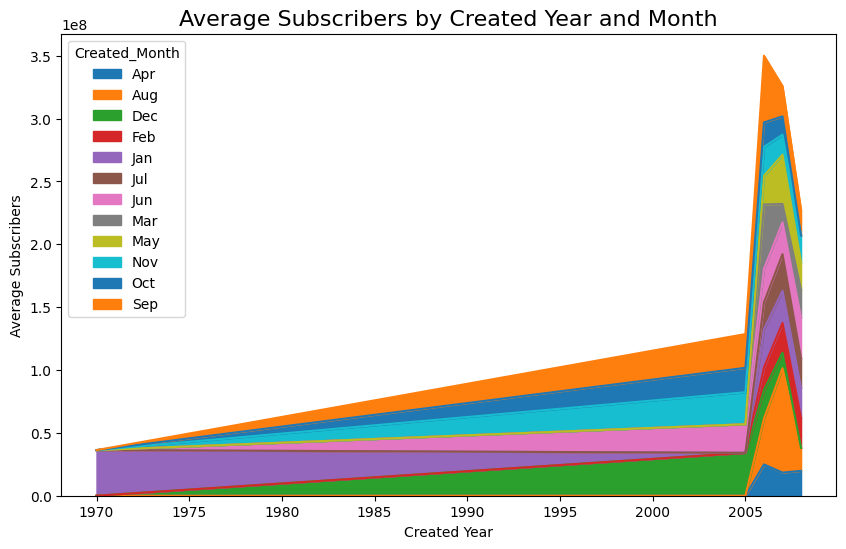

In [136]:
df.groupby(["Created_Year", "Created_Month"])["Subscribers"].mean().unstack().head().plot(
    kind="area",
    figsize=(10, 6),
    stacked=True
)
plt.title("Average Subscribers by Created Year and Month", fontsize=16)
plt.xlabel("Created Year")
plt.ylabel("Average Subscribers")
plt.show()

In [138]:
df.columns

Index(['Rank', 'Youtuber', 'Subscribers', 'Video Views', 'Category', 'Title',
       'Uploads', 'Country', 'Abbreviation', 'Channel_Type',
       'Video_Views_Rank', 'Country_Rank', 'Channel_Type_Rank',
       'Video_Views_For_The_Last_30_Days', 'Lowest_Monthly_Earnings',
       'Highest_Monthly_Earnings', 'Lowest_Yearly_Earnings',
       'Highest_Yearly_Earnings', 'Created_Year', 'Created_Month',
       'Created_Date', 'Gross Tertiary Education Enrollment (%)', 'Population',
       'Unemployment Rate', 'Urban_Population', 'Latitude', 'Longitude'],
      dtype='object')

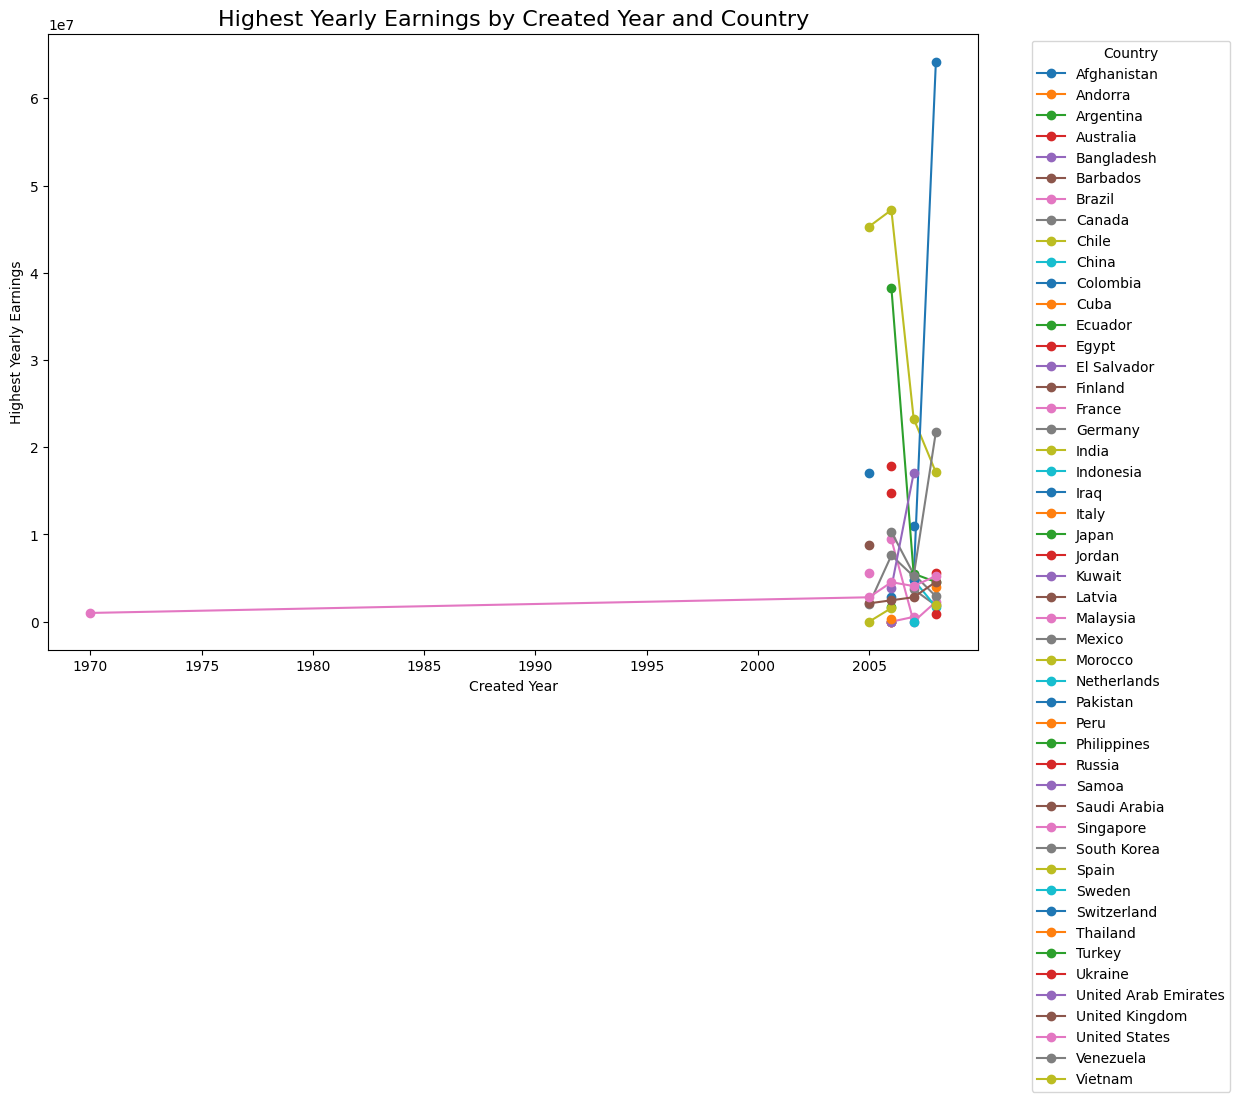

In [141]:
df.groupby(["Created_Year","Country"])["Highest_Yearly_Earnings"].mean().unstack().head().plot(kind="line",marker='o', figsize=(12,8))
plt.title("Highest Yearly Earnings by Created Year and Country", fontsize=16)
plt.xlabel("Created Year")
plt.ylabel("Highest Yearly Earnings")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [40]:
category_highly_monthly_earnings=df.groupby("Category")["Highest_Monthly_Earnings"].mean().sort_values(ascending=False)
category_highly_monthly_earnings

Category
Shows                    2.207467e+06
Autos & Vehicles         1.086350e+06
Pets & Animals           1.059233e+06
Sports                   8.069364e+05
Film & Animation         7.489841e+05
Entertainment            7.129257e+05
Comedy                   6.986864e+05
Education                6.951778e+05
News & Politics          6.426320e+05
People & Blogs           5.639309e+05
Music                    5.634572e+05
Movies                   4.547000e+05
Nonprofits & Activism    3.904000e+05
Trailers                 3.619000e+05
Gaming                   2.778164e+05
Science & Technology     2.146688e+05
Howto & Style            2.084243e+05
Travel & Events          1.240000e+05
Name: Highest_Monthly_Earnings, dtype: float64

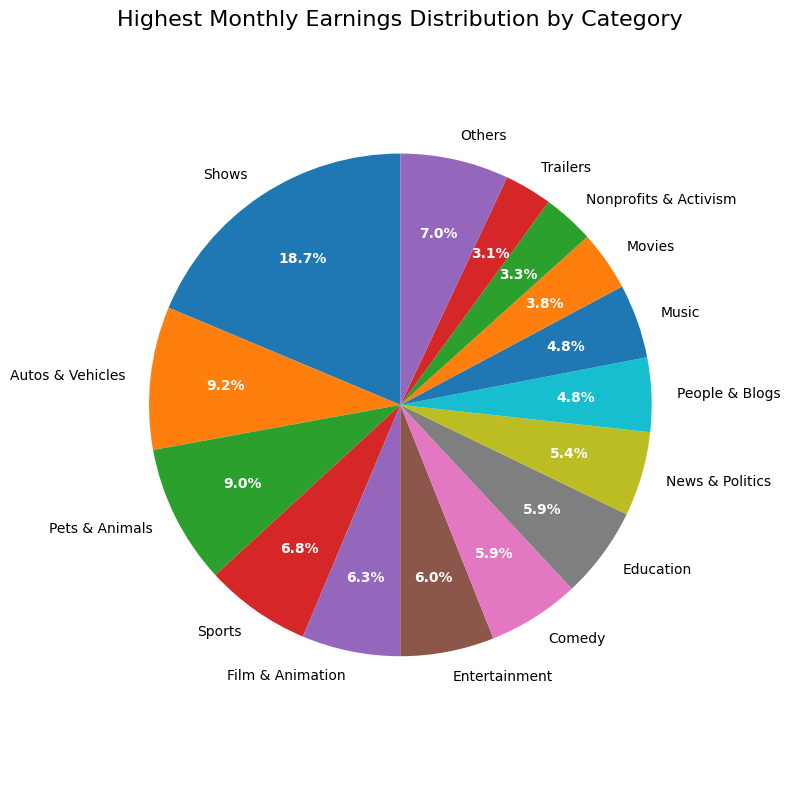

In [41]:
# Group small categories (<3%) into "Others"
threshold = 0.03 * category_highly_monthly_earnings.sum()
small = category_highly_monthly_earnings[category_highly_monthly_earnings < threshold]
large = category_highly_monthly_earnings[category_highly_monthly_earnings >= threshold]

earnings_grouped = large.copy()
earnings_grouped["Others"] = small.sum()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    earnings_grouped,
    labels=earnings_grouped.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7
)

# Style percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title("Highest Monthly Earnings Distribution by Category", fontsize=16)
ax.axis('equal')

plt.tight_layout()
plt.show()

In [43]:
channel_created_subscribers = df.groupby(["Created_Year", "Created_Month"])["Subscribers"].mean().unstack().head()



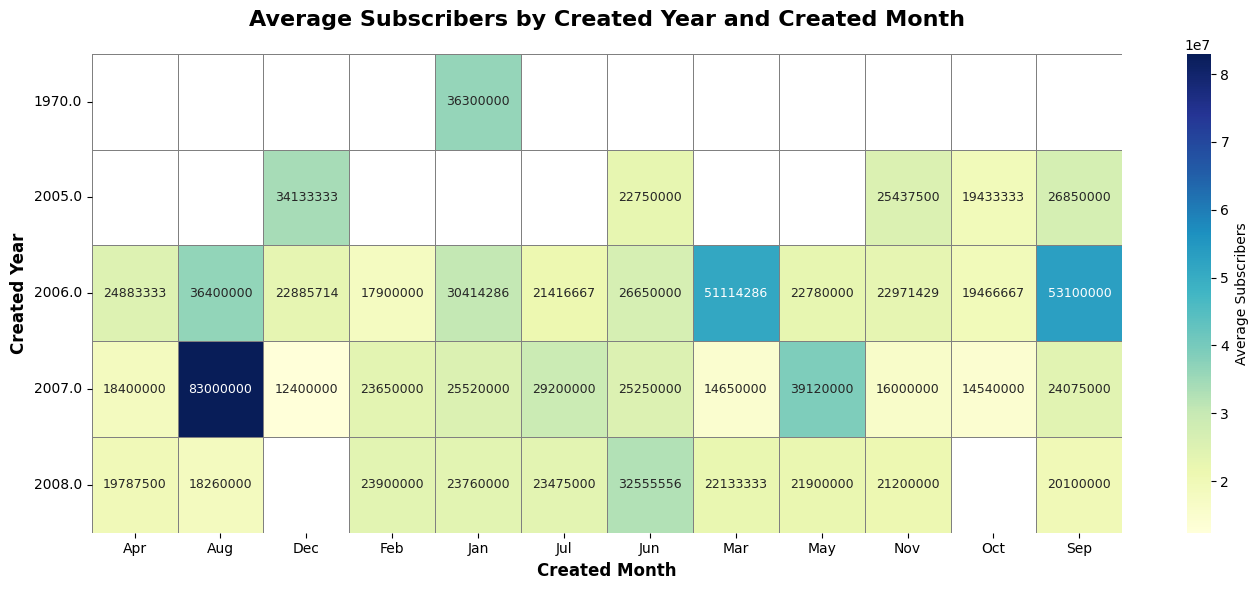

In [44]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    channel_created_subscribers, 
    annot=True, 
    fmt='.0f', 
    cmap='YlGnBu',
    cbar_kws={'label': 'Average Subscribers'},
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 9}
)

plt.title("Average Subscribers by Created Year and Created Month", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Created Year", fontsize=12, fontweight='bold')
plt.xlabel("Created Month", fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [153]:
df.columns.tolist()

['Rank',
 'Youtuber',
 'Subscribers',
 'Video Views',
 'Category',
 'Title',
 'Uploads',
 'Country',
 'Abbreviation',
 'Channel_Type',
 'Video_Views_Rank',
 'Country_Rank',
 'Channel_Type_Rank',
 'Video_Views_For_The_Last_30_Days',
 'Lowest_Monthly_Earnings',
 'Highest_Monthly_Earnings',
 'Lowest_Yearly_Earnings',
 'Highest_Yearly_Earnings',
 'Created_Year',
 'Created_Month',
 'Created_Date',
 'Gross Tertiary Education Enrollment (%)',
 'Population',
 'Unemployment Rate',
 'Urban_Population',
 'Latitude',
 'Longitude']

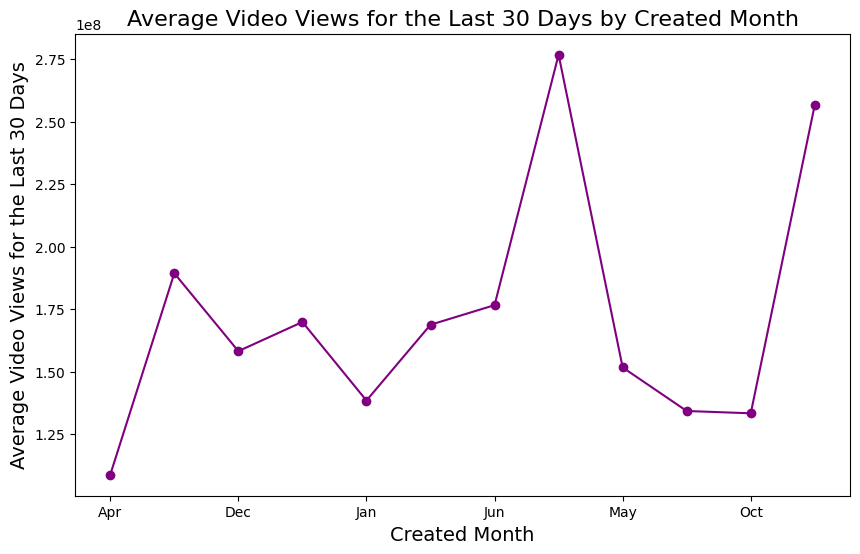

In [155]:
df.groupby("Created_Month")["Video_Views_For_The_Last_30_Days"].mean().plot(kind="line", figsize=(10,6), marker='o', color='purple')
plt.title("Average Video Views for the Last 30 Days by Created Month", fontsize=16)
plt.xlabel("Created Month", fontsize=14)
plt.ylabel("Average Video Views for the Last 30 Days", fontsize=14)
plt.show()